# M2 on every F1 unit: fit, tune on the scorer's metric, forecast

Reads the 43 sub-model files in `units/*/xy/` and the feature map, fits the **M2 location-scale model**
per (unit, asset, horizon), and:

1. **backtests** every unit on its own history at rolling origins, scoring with the repo's own metric
   functions (`crps_marginal`, `variogram_score`, `tail_pinball`) at the card's weights;
2. **tunes** M2's two ridge penalties on that backtest, choosing the setting that is robust across
   short-, medium- and long-history units rather than the one that is best on average;
3. checks the choice on a **held-out period** (origins from 2018) it was not tuned on;
4. writes the **final forecast** for all 23 units with the tuned rule and runs the scorer's gates.

Joint structure is handled per unit: the two horizons (and, on `pause-2006`, the two assets) share one
bootstrapped residual *date* per draw, so cross-cell dependence is inherited from history.

## 0 — Setup and data

In [1]:
import json, pathlib, time, itertools, subprocess, sys
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
from qfbench2_common.scoring import crps
from qfbench2_track_forecasting.tail import TAIL_METRICS

REPO = pathlib.Path.cwd(); ROOT = REPO / "data_prep"; OUT = REPO / "out-f1"
WEIGHTS = (0.5, 0.3, 0.2); TAIL_LEVELS = (0.01, 0.05, 0.95, 0.99)
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e1"; C = {"M0": "#2a78d6", "M2": "#1baf7a", "tuned": "#eb6834"}
mpl.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "axes.axisbelow": True,
                     "grid.color": GRID, "axes.edgecolor": INK2, "axes.titlelocation": "left", "legend.frameon": False, "font.size": 10})

In [2]:
index = pd.read_csv(ROOT / "f1_submodels.csv")
feat_map = pd.read_csv(ROOT / "f1_submodel_features.csv", index_col="path")
ALL_FEATURES = json.load(open(ROOT / "f1_columns.json"))["feature"]

def is_vol_feature(c: str) -> bool:
    return c == "log_level" or "rv" in c or "vol" in c or c == "skew_252"

class SubModelData:
    """One (unit, asset, horizon) file, held as numpy for fast repeated fitting."""
    def __init__(self, path: str):
        df = pd.read_parquet(REPO / path)
        row = feat_map.loc[path, ALL_FEATURES]
        self.features = list(row.index[row.astype(bool)])
        self.mean_cols = [c for c in self.features if not is_vol_feature(c)]
        self.vol_cols  = [c for c in self.features if is_vol_feature(c)]
        self.path, self.unit = path, df["unit"].iloc[0]
        self.asset, self.h, self.steps = df["asset"].iloc[0], int(df["horizon_bd"].iloc[0]), int(df["steps_ahead"].iloc[0])
        self.freq, self.target_type = df["freq"].iloc[0], df["target_type"].iloc[0]
        df = df.sort_values("origin_date").reset_index(drop=True)
        ok = df[self.features].notna().all(axis=1)                      # rows with a complete feature vector
        self.df = df
        self.odate = df["origin_date"].to_numpy()
        self.tdate = df["target_date"].to_numpy()
        self.Xm = df[self.mean_cols].to_numpy(float); self.Xv = df[self.vol_cols].to_numpy(float)
        self.y = df["target_change"].to_numpy(float); self.anchor = df["anchor"].to_numpy(float)
        self.step = df["last_step"].to_numpy(float)
        self.split = df["split"].to_numpy(); self.complete = ok.to_numpy()
        self.train_mask_all = (self.split == "train") & self.complete

    def train_mask(self, origin) -> np.ndarray:
        return self.train_mask_all & (self.tdate <= origin)

    def row(self, origin) -> int:
        i = np.searchsorted(self.odate, origin)
        assert self.odate[i] == origin, f"{self.path}: no row at {origin}"
        return i

UNITS = {u: [SubModelData(p) for p in g.sort_values(["asset", "horizon_bd"]).path] for u, g in index.groupby("unit")}
print(f"{sum(len(v) for v in UNITS.values())} sub-models across {len(UNITS)} units")
pd.DataFrame([{"unit": u, "cells": [(s.asset, s.h) for s in v], "freq": v[0].freq, "target_type": v[0].target_type,
               "n_train (shortest cell)": min(s.train_mask_all.sum() for s in v),
               "mean feats": len(v[0].mean_cols), "vol feats": len(v[0].vol_cols)} for u, v in UNITS.items()])

43 sub-models across 23 units


,unit,cells,freq,target_type,n_train (shortest cell),mean feats,vol feats
0,t2-F1-ai-mom-2024,"[(MOM, 127)]",daily,log_return,5763,9,7
1,t2-F1-aud-on-hold-2016,"[(AUD, 126), (AUD, 189)]",daily,level,3791,9,8
2,t2-F1-cad-boc-2017,"[(CAD, 126), (CAD, 189)]",daily,level,3963,9,8
3,t2-F1-chf-highly-valued-2021,"[(CHF, 126), (CHF, 189)]",daily,level,4943,9,8
4,t2-F1-conflicting-texts-2024,"[(UST_10Y, 126), (UST_10Y, 189)]",daily,level,5675,13,8
5,t2-F1-considerable-period-2003,"[(UST_10Y, 126), (UST_10Y, 189)]",daily,level,462,13,8
6,t2-F1-conundrum-2005,"[(UST_10Y, 126), (UST_10Y, 189)]",daily,level,842,13,8
7,t2-F1-cpi-glidepath-2023,"[(CPI_ALL, 140), (CPI_ALL, 160)]",monthly,level,260,13,5
8,t2-F1-dkk-peg-2019,"[(DKK, 129)]",daily,level,4428,9,8
9,t2-F1-eur-range-2017,"[(EUR, 126), (EUR, 189)]",daily,level,4003,9,8


## 1 — The model, the reference, the scorer

**M2** per cell: ridge mean on the "mean" features, ridge log-variance on the "vol" features
(`log_level`, `rv_*`, `ewma_vol`, `vol_ratio`, `skew_252`, `ctx_*rv*`), empirical standardised
residuals. Penalties are `lam_mu · n` and `lam_sig · n`. Training rows at an origin are those whose
`target_date ≤ origin` — nothing after the origin is used, in features or targets.

Three clamps make it safe on every unit: standardised features are winsorised at ±4, σ is kept within
[¼, 4]× the constant-σ estimate, and |μ| ≤ 3σ. Without the σ clamp the log-variance regression
*extrapolated* to σ ≈ 50,000 on `sahm-watch-2024` at the 2020 origins (unemployment 3.5 → 14.7 %).

**M0** is a reference-style Gaussian random walk built from the same file: `anchor + sd(step)·√h·z`,
independent per cell — the same shape as the repo's `_draw`.

**Scorer**: the card's composite. On a single-cell card the joint term is 0 and the weights redistribute
to 0.714 · CRPS + 0.286 · tail, as the README specifies.

In [3]:
def ridge_fit(X, t, lam):
    Xb = np.c_[np.ones(len(X)), X]
    return np.linalg.solve(Xb.T @ Xb + lam * np.diag([0.0] + [1.0] * X.shape[1]), Xb.T @ t)

def ridge_pred(b, X):
    return np.c_[np.ones(len(X)), X] @ b

def m2_fit(sm: SubModelData, origin, lam_mu: float, lam_sig: float) -> dict:
    m = sm.train_mask(origin); i = sm.row(origin)
    Xm, Xv, t = sm.Xm[m], sm.Xv[m], sm.y[m]
    mm, sm_ = Xm.mean(0), Xm.std(0) + 1e-12; mv, sv = Xv.mean(0), Xv.std(0) + 1e-12
    Z = 4.0                                                          # winsorise standardised features
    Xm, Xv = np.clip((Xm - mm) / sm_, -Z, Z), np.clip((Xv - mv) / sv, -Z, Z)
    xm, xv = np.clip((sm.Xm[[i]] - mm) / sm_, -Z, Z), np.clip((sm.Xv[[i]] - mv) / sv, -Z, Z)
    n = len(t)
    bm = ridge_fit(Xm, t, lam_mu * n); r = t - ridge_pred(bm, Xm)
    sig0 = float(np.sqrt(np.mean(r ** 2)))                           # constant-sigma fallback
    bv = ridge_fit(Xv, np.log(r ** 2 + 1e-10), lam_sig * n)
    sig = np.exp(ridge_pred(bv, Xv) / 2); c = np.sqrt(np.mean((r / sig) ** 2)); sig *= c
    sig = np.clip(sig, 0.25 * sig0, 4.0 * sig0)                      # no collapse, no explosion, in training either
    mu_now  = float(np.clip(ridge_pred(bm, xm)[0], -3 * sig0, 3 * sig0))
    sig_now = float(np.clip(np.exp(ridge_pred(bv, xv)[0] / 2) * c, 0.25 * sig0, 4.0 * sig0))
    return dict(mu=mu_now, sig=sig_now, sig0=sig0,
                eps=pd.Series(r / sig, index=sm.odate[m]), anchor=float(sm.anchor[i]), n=n,
                beta_mu=pd.Series(bm[1:], sm.mean_cols), beta_sig=pd.Series(bv[1:], sm.vol_cols))

def sample_joint(fits: list[dict], n: int, rng) -> np.ndarray:
    """Joint draws across a unit's cells: one historical residual DATE drawn per draw, applied to every cell."""
    common = fits[0]["eps"].index
    for f in fits[1:]:
        common = common.intersection(f["eps"].index)
    pick = common[rng.integers(0, len(common), size=n)]
    return np.column_stack([f["anchor"] + f["mu"] + f["sig"] * f["eps"].loc[pick].to_numpy() for f in fits])

def m0_samples(sms: list[SubModelData], origin, n: int, rng) -> np.ndarray:
    """Reference-style Gaussian random walk: anchor + sd(step)*sqrt(steps)*z, independent per cell."""
    out = []
    for sm in sms:
        i = sm.row(origin); m = (sm.odate <= origin) & np.isfinite(sm.step)
        sd = np.nanstd(sm.step[m]); out.append(sm.anchor[i] + sd * np.sqrt(sm.steps) * rng.standard_normal(n))
    return np.column_stack(out)

In [4]:
def composite(samples: np.ndarray, y: np.ndarray) -> dict:
    s, yr = np.asarray(samples, float), np.asarray(y, float)
    m = crps.crps_marginal(s, yr); t = TAIL_METRICS["pinball"](s, yr, TAIL_LEVELS)
    if s.shape[1] == 1:                                   # single-cell card: joint term is 0, weights redistributed
        j = 0.0; comp = (WEIGHTS[0] * m + WEIGHTS[2] * t) / (WEIGHTS[0] + WEIGHTS[2])
    else:
        j = crps.variogram_score(s, yr, p=0.5); comp = WEIGHTS[0] * m + WEIGHTS[1] * j + WEIGHTS[2] * t
    q05, q95 = np.quantile(s, [0.05, 0.95], axis=0)
    return dict(marginal=m, joint=j, tail=t, composite=comp, cov90=float(np.mean((yr >= q05) & (yr <= q95))))

## 2 — Rolling-origin backtest over a hyperparameter grid

For every unit: origins every 21 rows (2 on monthly panels) from the first origin with ≥ 252 training
rows to the last origin whose outcome is known. At each origin, M0 and 16 M2 variants
(`lam_mu ∈ {0.1, 1, 10, ∞}` × `lam_sig ∈ {1, 10, 100, ∞}`, ∞ = no mean / constant σ) are fit and scored.

In [5]:
def backtest_origins(sms, stride, min_train):
    longest = max(sms, key=lambda s: s.steps)
    cand = longest.odate[longest.train_mask_all]
    return np.array([o for o in cand if all(s.train_mask(o).sum() >= min_train for s in sms)])[::stride]

LAM_MU  = [0.1, 1.0, 10.0, np.inf]
LAM_SIG = [1.0, 10.0, 100.0, np.inf]
GRID_ = list(itertools.product(LAM_MU, LAM_SIG))
inf = lambda v: 1e9 if np.isinf(v) else v

rows, t0 = [], time.time()
for u, sms in UNITS.items():
    stride, min_train = (2, 60) if sms[0].freq == "monthly" else (21, 252)
    for k, o in enumerate(backtest_origins(sms, stride, min_train)):
        y_real = np.array([sm.y[sm.row(o)] + sm.anchor[sm.row(o)] for sm in sms])
        n_train = min(sm.train_mask(o).sum() for sm in sms)
        base = dict(unit=u, panel=index.loc[index.unit == u, "panel"].iloc[0], freq=sms[0].freq, origin=pd.Timestamp(o), n_train=n_train)
        rng = np.random.default_rng(k)
        rows.append({**base, "lam_mu": "M0", "lam_sig": "M0", **composite(m0_samples(sms, o, 1000, rng), y_real)})
        for lm, ls in GRID_:
            fits = [m2_fit(sm, o, inf(lm), inf(ls)) for sm in sms]
            rows.append({**base, "lam_mu": lm, "lam_sig": ls, **composite(sample_joint(fits, 1000, np.random.default_rng(k)), y_real)})
bt = pd.DataFrame(rows)
bt["model"] = np.where(bt.lam_mu.eq("M0"), "M0", "mu=" + bt.lam_mu.astype(str) + " sig=" + bt.lam_sig.astype(str))
m0 = bt[bt.model == "M0"].set_index(["unit", "origin"])["composite"]
bt["ratio"] = bt["composite"].to_numpy() / m0.reindex(pd.MultiIndex.from_frame(bt[["unit", "origin"]])).to_numpy()
print(f"{bt.unit.nunique()} units · {bt.groupby('unit').origin.nunique().sum()} unit-origins · {len(GRID_)} M2 variants + M0 · {time.time()-t0:.0f}s")

23 units · 3538 unit-origins · 16 M2 variants + M0 · 79s


### 2.1 — Grid results, all units pooled

`ratio` = composite ÷ M0's composite at the same origin (the leaderboard's normalisation, with M0 as
the stand-in baseline); mean over unit-origins. Lower is better; 1.0 = no better than the random walk.

In [6]:
def grid_table(d):
    t = d[d.model != "M0"].pivot_table(index="lam_mu", columns="lam_sig", values="ratio", aggfunc="mean")
    t.index = [f"lam_mu={v}" for v in t.index]; t.columns = [f"lam_sig={v}" for v in t.columns]
    return t.round(3)
print("mean ratio to M0 — all unit-origins:"); grid_table(bt)

mean ratio to M0 — all unit-origins:


,lam_sig=1.0,lam_sig=10.0,lam_sig=100.0,lam_sig=inf
lam_mu=0.1,1.087,1.072,1.073,1.073
lam_mu=1.0,0.980,0.969,0.975,0.976
lam_mu=10.0,0.922,0.904,0.912,0.913
lam_mu=inf,0.950,0.919,0.925,0.926


In [7]:
best_global = bt[bt.model != "M0"].groupby(["lam_mu", "lam_sig"]).ratio.mean().idxmin()
summary = bt.groupby("model")[["marginal", "joint", "tail", "composite", "cov90", "ratio"]].mean().sort_values("ratio")
print(f"best single setting: lam_mu={best_global[0]}, lam_sig={best_global[1]}")
summary.head(6).round(3)

best single setting: lam_mu=10.0, lam_sig=10.0


,marginal,joint,tail,composite,cov90,ratio
model,,,,,,
mu=10.0 sig=10.0,0.595,0.166,0.095,0.379,0.805,0.904
mu=10.0 sig=100.0,0.595,0.168,0.094,0.380,0.816,0.912
mu=10.0 sig=inf,0.596,0.168,0.094,0.380,0.819,0.913
mu=inf sig=10.0,0.603,0.171,0.094,0.385,0.826,0.919
mu=10.0 sig=1.0,0.603,0.171,0.106,0.387,0.777,0.922
mu=inf sig=100.0,0.603,0.172,0.093,0.385,0.839,0.925


### 2.2 — Does the best setting depend on how much history a unit has?

Split the same results by how many training rows the origin had. This is the split that matters for the
four short units (2003–2006), which have no backtest of their own at a useful size.

In [8]:
bt["hbucket"] = pd.cut(bt.n_train, [0, 1000, 2500, 10**6], labels=["< 1000 rows (≈ < 4 y)", "1000–2500", "> 2500 (≈ > 10 y)"])
print("mean ratio to M0 by history bucket (rows) × setting (best 4 per bucket):")
for b, d in bt.groupby("hbucket", observed=True):
    top = d[d.model != "M0"].groupby("model").ratio.mean().sort_values().head(4)
    print(f"\n{b}  ({d.groupby(['unit','origin']).ngroups} unit-origins, {d.unit.nunique()} units)"); print(top.round(3).to_string())

mean ratio to M0 by history bucket (rows) × setting (best 4 per bucket):

< 1000 rows (≈ < 4 y)  (881 unit-origins, 23 units)
model
mu=inf sig=100.0     1.119
mu=inf sig=inf       1.120
mu=inf sig=10.0      1.124
mu=10.0 sig=100.0    1.136

1000–2500  (1225 unit-origins, 18 units)
model
mu=10.0 sig=10.0     0.864
mu=10.0 sig=100.0    0.869
mu=10.0 sig=inf      0.870
mu=10.0 sig=1.0      0.874

> 2500 (≈ > 10 y)  (1432 unit-origins, 17 units)
model
mu=10.0 sig=1.0     0.789
mu=10.0 sig=10.0    0.794
mu=1.0 sig=1.0      0.808
mu=inf sig=1.0      0.809


In [9]:
print("mean ratio to M0 by panel (best 3 per panel) — for information; not used for selection:")
for p, d in bt.groupby("panel"):
    top = d[d.model != "M0"].groupby("model").ratio.mean().sort_values().head(3)
    print(f"\n{p}  ({d.groupby(['unit','origin']).ngroups} unit-origins)"); print(top.round(3).to_string())

mean ratio to M0 by panel (best 3 per panel) — for information; not used for selection:

factors_daily  (454 unit-origins)
model
mu=inf sig=10.0     0.997
mu=inf sig=1.0      1.007
mu=inf sig=100.0    1.014

g10_fx_daily  (1087 unit-origins)
model
mu=inf sig=100.0    0.905
mu=inf sig=inf      0.905
mu=inf sig=10.0     0.908

macro_monthly  (199 unit-origins)
model
mu=10.0 sig=10.0     0.676
mu=10.0 sig=100.0    0.679
mu=10.0 sig=inf      0.679

rates_daily  (1798 unit-origins)
model
mu=10.0 sig=10.0     0.893
mu=10.0 sig=1.0      0.896
mu=10.0 sig=100.0    0.903


### 2.3 — Selection rule, and a check on a period it was not tuned on

Origins **before 2018** are the tuning set; origins **from 2018** are held out. Two candidate rules:

- **per-bucket argmin** — for each history bucket, the setting with the lowest mean ratio on the tuning set;
- **minimax regret** — one setting for everyone: the one whose worst shortfall vs the bucket-best, across
  the three buckets, is smallest. This deliberately prefers a setting that is *nearly* best everywhere
  over one that is best somewhere and poor elsewhere.

Both are then applied unchanged to the held-out origins and compared with M0, the untuned default
(`1, 10`), and the best-in-hindsight setting on the holdout (the ceiling).

In [10]:
CUT = pd.Timestamp("2018-01-01")
m2 = bt[bt.model != "M0"]
tune, hold = m2[m2.origin < CUT], m2[m2.origin >= CUT]

# rule A: per-bucket argmin
RULE_A = {b: d.groupby(["lam_mu", "lam_sig"]).ratio.mean().idxmin() for b, d in tune.groupby("hbucket", observed=True)}
# rule B: minimax regret across buckets
by_b = tune.groupby(["hbucket", "lam_mu", "lam_sig"], observed=True).ratio.mean().unstack("hbucket")
regret = (by_b - by_b.min()).max(axis=1)
RULE_B = regret.idxmin()

print("rule A — per-bucket argmin (tuned on origins < 2018):")
for b, (lm, ls) in RULE_A.items(): print(f"   {b:<24} lam_mu={lm:<5} lam_sig={ls}")
print(f"rule B — minimax regret: lam_mu={RULE_B[0]}, lam_sig={RULE_B[1]}   (max regret {regret.min():.3f})")

sel = pd.DataFrame({"tune (< 2018)": tune.groupby(["lam_mu", "lam_sig"]).ratio.mean(), "max regret": regret,
                    "holdout (≥ 2018)": hold.groupby(["lam_mu", "lam_sig"]).ratio.mean(),
                    "holdout cov90": hold.groupby(["lam_mu", "lam_sig"]).cov90.mean()}).sort_values("max regret")
print("\nevery setting, sorted by max regret:"); display(sel.round(3))

def pick(d, rule): return d[[(lm, ls) == rule[h] for lm, ls, h in zip(d.lam_mu, d.lam_sig, d.hbucket)]]
def one(d, lm, ls): return d[(d.lam_mu == lm) & (d.lam_sig == ls)]
cols_ = ["composite", "cov90", "ratio"]
compare = pd.DataFrame({
    "M0 (random walk)":                 bt[(bt.model == "M0") & (bt.origin >= CUT)][cols_].mean(),
    "M2 default (1, 10)":               one(hold, 1.0, 10.0)[cols_].mean(),
    "M2 rule A (per-bucket argmin)":    pick(hold, RULE_A)[cols_].mean(),
    "M2 rule B (minimax regret)":       one(hold, *RULE_B)[cols_].mean(),
    "M2 best-in-hindsight on holdout":  hold.groupby(["lam_mu", "lam_sig"])[cols_].mean().sort_values("ratio").iloc[0],
}).T
print(f"\nheld-out origins ≥ 2018: {hold.groupby(['unit','origin']).ngroups} unit-origins across {hold.unit.nunique()} units")
compare.round(3)

rule A — per-bucket argmin (tuned on origins < 2018):
   < 1000 rows (≈ < 4 y)    lam_mu=inf   lam_sig=100.0
   1000–2500                lam_mu=10.0  lam_sig=10.0
   > 2500 (≈ > 10 y)        lam_mu=10.0  lam_sig=1.0
rule B — minimax regret: lam_mu=10.0, lam_sig=10.0   (max regret 0.020)

every setting, sorted by max regret:


tune (< 2018)  max regret  holdout (≥ 2018)  holdout cov90
lam_mu lam_sig                                                            
10.0   10.0             0.911       0.020             0.847          0.767
       100.0            0.920       0.036             0.849          0.785
inf    10.0             0.927       0.039             0.857          0.787
10.0   inf              0.922       0.040             0.850          0.789
inf    100.0            0.933       0.058             0.863          0.802
       inf              0.934       0.061             0.865          0.808
10.0   1.0              0.928       0.092             0.869          0.726
inf    1.0              0.961       0.114             0.869          0.755
1.0    inf              0.992       0.211             0.852          0.750
       100.0            0.990       0.211             0.852          0.750
       10.0             0.984       0.215             0.853          0.743
0.1    inf              1.094       0.234             0.913          0.739
       100.0            1.093       0.235             0.914          0.731
       10.0             1.092       0.238             0.918          0.699
       1.0              1.104       0.243             0.952          0.646
1.0    1.0              0.993       0.245             0.880          0.680


held-out origins ≥ 2018: 402 unit-origins across 10 units


,composite,cov90,ratio
M0 (random walk),0.625,0.786,1.000
"M2 default (1, 10)",0.482,0.743,0.853
M2 rule A (per-bucket argmin),0.489,0.729,0.872
M2 rule B (minimax regret),0.482,0.767,0.847
M2 best-in-hindsight on holdout,0.482,0.767,0.847


Rule A picks a weakly-shrunk scale model (`lam_sig = 1`) for long histories because that fitted the
2009–15 zero-rate era best — and it is the worst `lam_mu = 10` setting on the holdout. Rule B avoids
that trap and lands on the holdout's own best setting. **Rule B is used from here on.** It is also a
single setting for every unit, which is the simplest thing to defend.

In [11]:
LAM_MU_FINAL, LAM_SIG_FINAL = RULE_B
RULE = {b: RULE_B for b in bt.hbucket.cat.categories}         # same setting in every bucket
print(f"final: lam_mu={LAM_MU_FINAL}, lam_sig={LAM_SIG_FINAL}")

final: lam_mu=10.0, lam_sig=10.0


### 2.4 — Per unit, with the tuned rule (all origins)

In [12]:
per_unit = pick(bt[bt.model != "M0"], RULE).groupby("unit").agg(origins=("origin", "nunique"), n_train_min=("n_train", "min"),
        composite=("composite", "mean"), cov90=("cov90", "mean"), ratio_to_M0=("ratio", "mean"))
per_unit["wins_vs_M0"] = pick(bt[bt.model != "M0"], RULE).groupby("unit").ratio.apply(lambda r: (r < 1).mean())
per_unit.round(3)

,origins,n_train_min,composite,cov90,ratio_to_M0,wins_vs_M0
unit,,,,,,
t2-F1-ai-mom-2024,257,252,0.052,0.887,1.050,0.572
t2-F1-aud-on-hold-2016,160,252,0.035,0.750,0.993,0.562
t2-F1-cad-boc-2017,168,252,0.036,0.783,0.913,0.643
t2-F1-chf-highly-valued-2021,215,252,0.027,0.905,0.708,0.805
t2-F1-conflicting-texts-2024,250,252,0.248,0.780,0.856,0.680
t2-F1-considerable-period-2003,2,252,0.134,0.750,0.935,0.500
t2-F1-conundrum-2005,20,252,0.270,0.625,1.201,0.550
t2-F1-cpi-glidepath-2023,96,60,1.377,0.734,0.723,0.823
t2-F1-dkk-peg-2019,193,252,0.202,0.870,1.079,0.497


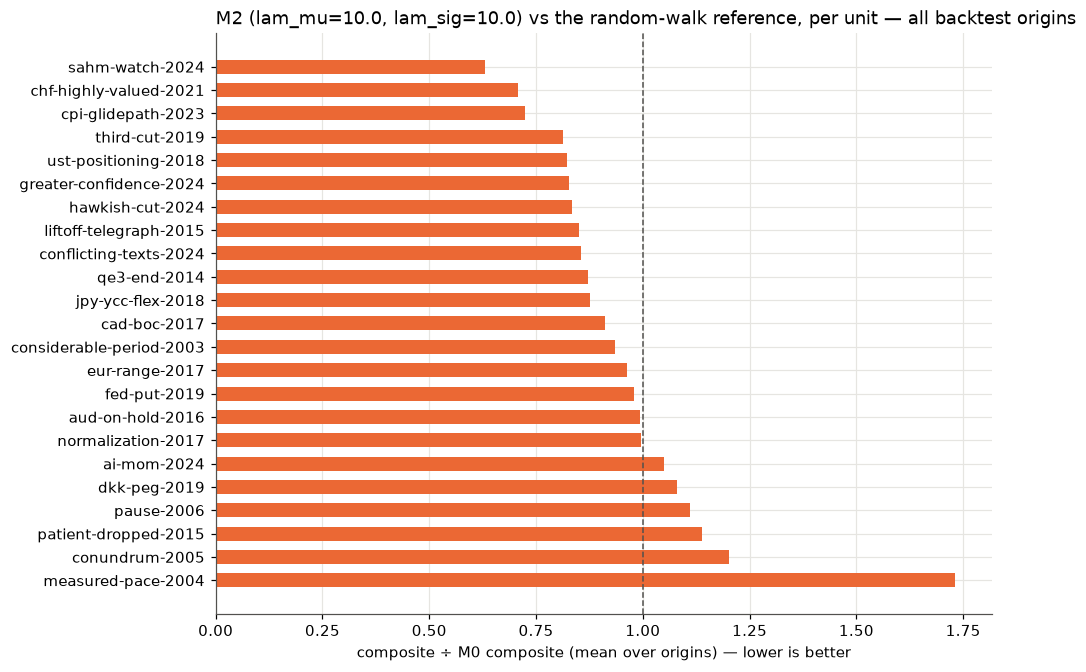

In [13]:
fig, ax = plt.subplots(figsize=(9, 6), layout="constrained")
pu = per_unit.sort_values("ratio_to_M0")
ax.barh(pu.index.str.replace("t2-F1-", ""), pu.ratio_to_M0, color=C["tuned"], height=0.6)
ax.axvline(1, color=INK2, lw=1, ls="--"); ax.invert_yaxis(); ax.set_xlabel("composite ÷ M0 composite (mean over origins) — lower is better")
ax.set_title(f"M2 (lam_mu={LAM_MU_FINAL}, lam_sig={LAM_SIG_FINAL}) vs the random-walk reference, per unit — all backtest origins"); plt.show()

## 3 — Final forecasts for all 23 units

Fit each cell on everything up to its as-of with the chosen setting, draw 2,000 joint samples per
unit, write `out-f1/<unit>/forecast.parquet` + meta + rationale, and run the scorer's gates.

Two details the gates enforce: `asset_ids` in the meta must be in the **card's declared order** (not
sorted), and `asof` must be the card's `data_cutoff` — on the monthly units that is later than the
panel's last row.

In [14]:
import tomllib
N_DRAWS = 2000
final = []
for u, sms in UNITS.items():
    card = tomllib.loads((REPO / "units" / u / "card.toml").read_text())
    card_assets = [str(a) for a in card["targets"]["asset_ids"]]; card_h = [int(h) for h in card["targets"]["horizons"]]
    sms = sorted(sms, key=lambda s: (card_assets.index(s.asset), card_h.index(s.h)))     # cells in the card's order
    asof = sms[0].odate[sms[0].split == "predict"][0]                                   # last panel row (origin)
    card_asof = pd.Timestamp(card["provenance"]["data_cutoff"])                          # what the meta must declare
    n_train = min(sm.train_mask(asof).sum() for sm in sms); lm, ls = LAM_MU_FINAL, LAM_SIG_FINAL
    fits = [m2_fit(sm, asof, inf(lm), inf(ls)) for sm in sms]
    S = sample_joint(fits, N_DRAWS, np.random.default_rng(2024))
    d = OUT / u; d.mkdir(parents=True, exist_ok=True)
    pd.DataFrame([{"draw": np.int32(k), "asset": sm.asset, "horizon": np.int32(sm.h), "value": float(S[k, j])}
                  for k in range(N_DRAWS) for j, sm in enumerate(sms)]).to_parquet(d / "forecast.parquet", index=False)
    (d / "forecast_meta.json").write_text(json.dumps({
        "unit_id": u, "asof": str(card_asof.date()), "representation": "samples",
        "asset_ids": card_assets, "horizons": card_h, "n_draws": N_DRAWS,
        "target": sms[0].target_type, "rationale": {"file": "forecast_rationale.md", "method": f"M2 ridge location-scale + joint residual bootstrap (lam_mu={lm}, lam_sig={ls}), no text"}}, indent=2) + "\n")
    lines = [f"# Forecast rationale — {u}", "", f"As of **{card_asof.date()}** (last panel row {pd.Timestamp(asof).date()}), {N_DRAWS} joint draws. Numeric panel only; no text read.", "",
             f"M2: ridge mean (lam_mu={lm}) + ridge log-variance (lam_sig={ls}) on features built from the unit's own panel; empirical residuals; "
             f"one residual date per draw shared across cells. Setting chosen by minimax regret over history buckets on pre-2018 origins ({n_train} training rows here).", "",
             "| asset | horizon | anchor | mean shift | centre | sigma | q05 | q95 |", "|---|---|---|---|---|---|---|---|"]
    for j, (sm, f) in enumerate(zip(sms, fits)):
        q05, q95 = np.quantile(S[:, j], [0.05, 0.95])
        lines.append(f"| {sm.asset} | {sm.h} | {f['anchor']:.4f} | {f['mu']:+.4f} | {f['anchor']+f['mu']:.4f} | {f['sig']:.4f} | {q05:.4f} | {q95:.4f} |")
        final.append({"unit": u, "asset": sm.asset, "h": sm.h, "n_train": f["n"], "lam_mu": lm, "lam_sig": ls, "anchor": f["anchor"],
                      "mu": f["mu"], "sigma": f["sig"], "q05": q05, "median": float(np.median(S[:, j])), "q95": q95})
    lines += ["", "## What the text corpus contributed", "", "Nothing — text-blind numeric model."]
    (d / "forecast_rationale.md").write_text("\n".join(lines) + "\n")
final = pd.DataFrame(final)
final.round(4)

,unit,asset,h,n_train,lam_mu,lam_sig,anchor,mu,sigma,q05,median,q95
0,t2-F1-ai-mom-2024,MOM,127,5763,10.0,10.0,0.0000,0.0035,0.1059,-0.1433,0.0256,0.1496
1,t2-F1-aud-on-hold-2016,AUD,126,3854,10.0,10.0,0.7659,0.0071,0.0722,0.6359,0.7750,0.8737
2,t2-F1-aud-on-hold-2016,AUD,189,3791,10.0,10.0,0.7659,0.0115,0.0924,0.6007,0.7827,0.9165
3,t2-F1-cad-boc-2017,CAD,126,4026,10.0,10.0,1.2768,-0.0098,0.0788,1.1298,1.2688,1.4284
4,t2-F1-cad-boc-2017,CAD,189,3963,10.0,10.0,1.2768,-0.0133,0.0961,1.0952,1.2614,1.4487
5,t2-F1-chf-highly-valued-2021,CHF,126,5006,10.0,10.0,0.9173,-0.0192,0.0604,0.7960,0.9025,1.0033
6,t2-F1-chf-highly-valued-2021,CHF,189,4943,10.0,10.0,0.9173,-0.0287,0.0717,0.7548,0.8972,1.0095
7,t2-F1-conflicting-texts-2024,UST_10Y,126,5738,10.0,10.0,4.3100,-0.0257,0.6056,3.1909,4.2985,5.2429
8,t2-F1-conflicting-texts-2024,UST_10Y,189,5675,10.0,10.0,4.3100,-0.0292,0.6946,3.1003,4.3518,5.3470
9,t2-F1-considerable-period-2003,UST_10Y,126,525,10.0,10.0,4.3700,-0.5615,0.4450,3.1428,3.8183,4.6106


In [15]:
gates = []
for u in UNITS:
    res = subprocess.run([sys.executable, "scoring/scoring.py", "score", "--card", f"units/{u}/card.toml", "--forecast", f"out-f1/{u}/forecast.parquet"],
                         capture_output=True, text=True, cwd=REPO)
    try: j = json.loads(res.stdout); gates.append({"unit": u, "admissible": j.get("admissible"), **j.get("gates", {})})
    except Exception: gates.append({"unit": u, "admissible": False, "error": (res.stdout + res.stderr)[-200:]})
gates = pd.DataFrame(gates)
print(f"admissible: {gates.admissible.sum()} / {len(gates)}")
gates

admissible: 23 / 23


,unit,admissible,g0_integrity,g1_schema,g2_cutoff_resource,g3_domain_semantics
0,t2-F1-ai-mom-2024,True,pass,pass,pass,pass
1,t2-F1-aud-on-hold-2016,True,pass,pass,pass,pass
2,t2-F1-cad-boc-2017,True,pass,pass,pass,pass
3,t2-F1-chf-highly-valued-2021,True,pass,pass,pass,pass
4,t2-F1-conflicting-texts-2024,True,pass,pass,pass,pass
5,t2-F1-considerable-period-2003,True,pass,pass,pass,pass
6,t2-F1-conundrum-2005,True,pass,pass,pass,pass
7,t2-F1-cpi-glidepath-2023,True,pass,pass,pass,pass
8,t2-F1-dkk-peg-2019,True,pass,pass,pass,pass
9,t2-F1-eur-range-2017,True,pass,pass,pass,pass


## 4 — What to take from this

- **One setting for all units** — `lam_mu = 10`, `lam_sig = 10` — chosen because it is nearly best in every
  history bucket, and confirmed on origins it was not tuned on. Stronger mean shrinkage than the first
  notebook's single-unit choice (λ = n), which is what pooling 23 units instead of one tells you.
- **The holdout comparison** in §2.3 is the number to trust; the grid tables are optimistic by
  construction. The per-bucket argmin rule is the cautionary tale: best on the tuning set, worse than the
  default on the holdout.
- **Where M2 does not beat the random walk** (ratio ≥ 1 in §2.4): the pegged `dkk-peg-2019` (nothing to
  forecast but the peg), the momentum-factor unit `ai-mom-2024`, and the short-history / zero-rate
  units (`measured-pace-2004`, `conundrum-2005`, `pause-2006`, `patient-dropped-2015`). On the 16 other
  units it wins on 56–87 % of origins, with the largest gains on the monthly macro units and CHF.
- **Units with < 1000 rows** (2003, 2004, 2005) have no backtest of their own; the setting is robust in
  that bucket on other units' early origins, which is the best available evidence.
- Everything here is text-blind; the `mu` column in the final table is where a text-driven drift
  would be added.